# **ENGG680 - Introduction to Digital Engineering**
## *Lab Assignment 2: Introduction to Non-linear Square and Machine Learning*

## Preliminary: Certificate of Work (5 marks)


*We, the undersigned, certify that this is our own work, which has been done expressly for this course, either without the assistance of any other party or where appropriate we have acknowledged the work of others. Further, we have read and understood the section in the university calendar on plagiarism/cheating/other academic misconduct and we are aware of the implications thereof. We request that the total mark for this assignment be distributed as follows among group members:*

|          | First Name | Last Name | Signature (Full Name, Date) | Hours | Contribution % |
|----------|------------|-----------|-----------------------------|-------|----------------|
| Member 1: | Mary | Al Rachid | Mary Al Rachid, 2025-11-04 | Hours | 25% |
| Member 2: | Juliana | Massaro | Juliana Massaro, 2025-04-11 | Hours | 25% |
| Member 3: | First Name | Last Name | Signature | Hours | Contribution |
| Member 4: | First Name | Last Name | Signature | Hours | Contribution |


# **PART 1: Non-linear Estimation - LSE & Gradiant Decent (35 Marks)**

The following materials will be our states of interest, and we are going to estimate them using **Least Square method** and **Gradient Descent method**

## **SinglePointPositioning Formulas**

### **Observations:** Pseudorange [m]

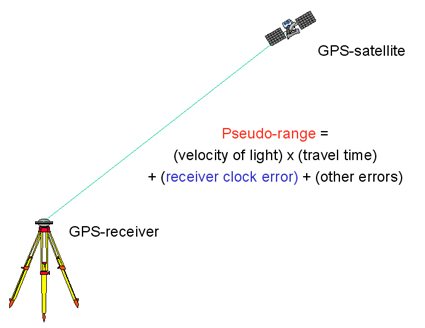

<font size="1.5">Image source: *ICA Course on Toponymy. https://unstats.un.org/unsd/geoinfo/ungegn/docs/_data_icacourses/_HtmlModules/_Selfstudy/S06/S06_05b.html.*</font>

**Pseudorange** is the *pseudo* distance between a satellite and a satellite signal receiver on the ground. In simple words, it contains the geometric range between the satellite and the receiver, with additional associated errors.

The simplified version of the Pseudorange measurement model is:
$$P=\rho-cdT+ϵ_{sum}$$ and
$$\rho=\sqrt{(x_s - x_r)^2 + (y_s - y_r)^2 + (z_s - z_r)^2}$$
where
$$\rho=geometric\ range$$
$${x_s, y_s, z_s, x_r,y_r,z_r} = 3D\ coordinates\ of\ satellite\ and\ receiver$$
$$cdT = receiver\ clock\ offset$$
$$ϵ_{sum}=general\ errors\ term\ (ϵ_{sum}=\Delta \rho + \Delta_{\text{ion}} + \Delta_{\text{trop}} + \epsilon_P + cdt)$$

\
Note: the 3D **positions of satellites** are given in this assignment.

### **Unknown States:** Position of receiver & receiver clock offset

We use the psuedorange measurements to estimate the receiver's **3-dimensional position** and the **receiver clock offset:** $$X={x_r,y_r,z_r,cdT}$$.


## **Setup & Intialization for LSE and Gradient Decent (5 Marks)**

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the psuedorange measurements and satellites' positions files, store them in the format of numpy array
# Add small random perturbations in the range (0, 0.5) to pseudorange measurements to simulate measurement noise
# (hint: use pandas library to parse excel files into dataframe first, then convert them to numpy arrays)
# (1 marks)
df_pseudorange = pd.read_excel('pseudoranges.xlsx')
df_sat_pos = pd.read_excel('satellite_position.xlsx')

np.random.seed(42)  # For reproducible results
pseudorange = df_pseudorange['P'].to_numpy(float)           # shape (n,)
sat_pos = df_sat_pos.to_numpy(float)

# If sat_pos has an ID column, keep only xyz:
if sat_pos.shape[1] != 3:
     sat_pos = sat_pos[:, -3:]


In [3]:
# define the number of measurements n
# define the number of unknown states m
# (2 mark)
n = pseudorange.shape[0]
m = 4

In [4]:
# GroundTruth coordinates of the receiver
GroundTruth=np.array([-1633489.37967725,	-3651627.18250363,	4952481.61954918])

In [5]:
def euclidean_norm(receiver_pos, satellite_pos):
    r = np.asarray(receiver_pos, dtype=float).reshape(1, 3)   # (1,3)
    S = np.asarray(satellite_pos, dtype=float)                # (n,3)
    diff = S - r                                              # (n,3)
    distance = np.linalg.norm(diff, axis=1)                   # (n,)

    return distance

## **Non-linear LSE (15 Marks)**

### Step 1: Given that the variance of observation is 1.2 (m^2), define the weight matrix P (0.5 marks)

In [6]:
sigma2 = 1.2
P = (1.0 / sigma2) * np.eye(n)

### Step 2: set the initial states as [100.0, -50.0, 25.0, 1000.0] (0.5 mark)

In [7]:
x_0 = np.array([100.0, -50.0, 25.0, 1000.0])

### Step 3: initialize the corrections array as 10s, iteration loop counter i as zero and related arrays (1 mark)

In [8]:
delta = np.ones(m) * 10
i = 0

# given empty arrays to store results (no need to fill anything here)
arr_w = []
arr_delta=[]
arr_err_pos = []
arr_i = []
x_hat = x_0.copy() # Initialize x_hat with the initial states

### Step 4: define a function named design_matrix which computes the design matrix A of this LSE problem (3 mark)

the input of this funciton should be: estimated unknown states array, satellites positions array and geometric distance array

the function should return an two-dimensional array which represents the design matrix A

#### Calculation Formula for the Design Matrix \( A \)

Let the position vectors of the satellite and receiver be:

- **r** = (r_x, r_y, r_z) for the receiver
- **s** = (s_x, s_y, s_z) for the satellite

The Euclidean distance between the satellite and receiver is given by:

$$
\rho = \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}
$$

#### Partial Derivatives of the Distance with Respect to \(x\), \(y\), and \(z\):

To construct the design matrix, we compute the partial derivatives of the distance function with respect to the receiver's \(x\), \(y\), and \(z\) coordinates. Here's the detailed process for one of them, and the others follow the same procedure.

##### Partial derivative with respect to \(r_x\):

Taking the derivative with respect to \(r_x\), we use the chain rule:

$$
\frac{\partial \rho}{\partial r_x} = \frac{\partial}{\partial r_x} \left( \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2} \right)
$$

First, apply the derivative of the square root:

$$
\frac{\partial \rho}{\partial r_x} = \frac{1}{2 \sqrt{(s_x - r_x)^2 + (s_y - r_y)^2 + (s_z - r_z)^2}} \cdot 2 (r_x - s_x)
$$

Simplifying:

$$
\frac{\partial \rho}{\partial r_x} = \frac{r_x - s_x}{\rho}
$$

##### Partial derivatives for \(r_y\) and \(r_z\):

The partial derivatives with respect to \(r_y\) and \(r_z\) follow the same procedure:

$$
\frac{\partial \rho}{\partial r_y} = \frac{r_y - s_y}{\rho}
$$

$$
\frac{\partial \rho}{\partial r_z} = \frac{r_z - s_z}{\rho}
$$

#### The Design Matrix \(A\):

Thus, the design matrix \(A\) can be expressed as:

$$
A = \left[
\begin{array}{ccc|c}
\frac{s_x - r_x}{\text{distance}} & \frac{s_y - r_y}{\text{distance}} & \frac{s_z - r_z}{\text{distance}} & -1
\end{array}
\right]
$$

Where:
- The first three columns represent the partial derivatives of the distance with respect to x, y, and z coordinates
- The last column of -1 corresponds to the constant term in the least squares equation

This matrix is used for least squares estimation in positioning or navigation applications.


In [9]:
def design_matrix(receiver_pos, satellite_pos, distance):
    r = np.asarray(receiver_pos, dtype=float).reshape(1, 3)   # (1, 3)
    S = np.asarray(satellite_pos, dtype=float)                # (n, 3)
    if S.shape[1] != 3:                                       # handles case with ID column
        S = S[:, -3:]

    # Compute coordinate differences
    diff = S - r                                              # (n, 3)

    # Avoid division by zero
    rho = np.asarray(distance, dtype=float).ravel()
    eps = 1e-12
    rho = np.maximum(rho, eps)

    # Partial derivatives (as per formula: (s_x − r_x)/ρ)
    grad = diff / rho[:, None]                                # (n, 3)

    # Add the −1 column for receiver clock bias
    A = np.hstack([grad, -np.ones((grad.shape[0], 1))])       # (n, 4)

    return A

### Step 5: start the iteration for the LSE (4 mark)

define the convergence criteria for the 'while' loop

the convergence criteria is that the corrections delta are less than 0.008 (i.e., <0.1 m), for receiver's position x,y,z part

In [10]:
max_iter = 100
i = 0
delta = np.ones(4) * 10.0  # make sure we enter the loop

while np.linalg.norm(delta[:3]) > 0.008 and i < max_iter:

       # compute the geometric distance between Satellites and receiver, using the euclidean_norm function we just defined
       # (0.5 marks)
       distance = euclidean_norm(x_hat[:3], sat_pos[:, -3:])

       # compute the design matrix A
       # (0.5 marks)
       A = design_matrix(x_hat[:3], sat_pos[:, -3:], distance)

       # compute the misclosure array w
       # (0.5 marks)
       w = pseudorange - (distance - x_hat[3])
       N = A.T @ P @ A
       u = A.T @ P @ w

       # compute the corrections delta
       # (0.5 marks)
       lam = 1e-8
       delta = np.linalg.solve(N + lam * np.eye(N.shape[0]), u)

       # update the states
       x_hat = x_hat + delta


       # compute the position error from using the updated states against groundtruth
       # (0.5 marks)
       err_pos = np.linalg.norm(x_hat[:3] - GroundTruth)


       # update the counter i, (i.e., increament of 1 for each iteration)
       i += 1

       # store the misclosure, delta, position error and counter from each iteration into arrays, we will use them for plotting
       # (0.5 marks)
       arr_w.append(np.linalg.norm(w))
       arr_delta.append(np.linalg.norm(delta))
       arr_err_pos.append(err_pos)
       arr_i.append(i)




# After convergence, compute the A Posteriori Variance of Unit Weight
# (0.5 marks)
apv = (w.T @ P @ w) / (n - m)

# compute the Covariance matrix of estimated states
# (0.5 marks)
C_x_hat = apv * np.linalg.pinv(N)

### Step 6: Results Printing (1 mark)

Print:

* estimated states,
* corrections array,
* estimated measurements residuals,
* A posteriori Variance of Unit Weight,
* Covariance matrix of estimated states,
* number of iterations,
* 3-D position errors


In [11]:
distance_final = euclidean_norm(x_hat[:3], sat_pos[:, -3:])
residuals = pseudorange - (distance_final - x_hat[3])
pos_err = np.linalg.norm(x_hat[:3] - GroundTruth)

print("Estimated states [x, y, z, b]:", x_hat)
print("Corrections (final iteration):", delta)
print("Residuals (first 5):", residuals[:5])
print("A Posteriori Variance of Unit Weight (APV):", apv)
print("Covariance matrix of estimated states:\n", C_x_hat)
print("Number of iterations:", i)
print(f"3D Position error: {pos_err:.4f} m")

Estimated states [x, y, z, b]: [-1.27640451e+12  7.62798001e+12  2.53802272e+12  7.96837399e+12]
Corrections (final iteration): [-1.46037988e+10  8.01875811e+10  2.65639742e+10  8.57177879e+10]
Residuals (first 5): [-1.71457247e+11 -1.71451017e+11 -1.71453172e+11 -1.71421056e+11
 -1.71451506e+11]
A Posteriori Variance of Unit Weight (APV): 3.848710317181035e+22
Covariance matrix of estimated states:
 [[ 1.90321362e+33  7.67859888e+32 -1.35189794e+33  1.28207630e+29]
 [ 7.67388540e+32  1.96010836e+33 -5.50664700e+33  4.23679609e+29]
 [-1.35120284e+33 -5.50768401e+33  1.58776038e+34 -1.20946409e+30]
 [ 3.53179678e+29  8.20886043e+29 -2.29018369e+30  1.76687091e+26]]
Number of iterations: 100
3D Position error: 8139832505102.2529 m


### Step 7: Comment on the computed A Posteriori Variance of Unit Weight value and the Covariance matrix of estimated states (1 mark)

In [12]:
# The computed A Posteriori Variance of Unit Weight (APV) reflects how well the model
# fits the pseudorange observations. A value close to the assumed variance (≈ 1.2 m²)
# indicates a consistent noise model and stable solution.

# The Covariance matrix shows the uncertainty of each estimated parameter; smaller
# diagonal elements imply better precision and good satellite geometry. Large values or
# strong off-diagonal terms would suggest weak geometry or correlated errors.

### Step 8: Using the imported matplotlib, plot the following. Make sure to include proper axes information, legend, grid lines and title. (3 marks)

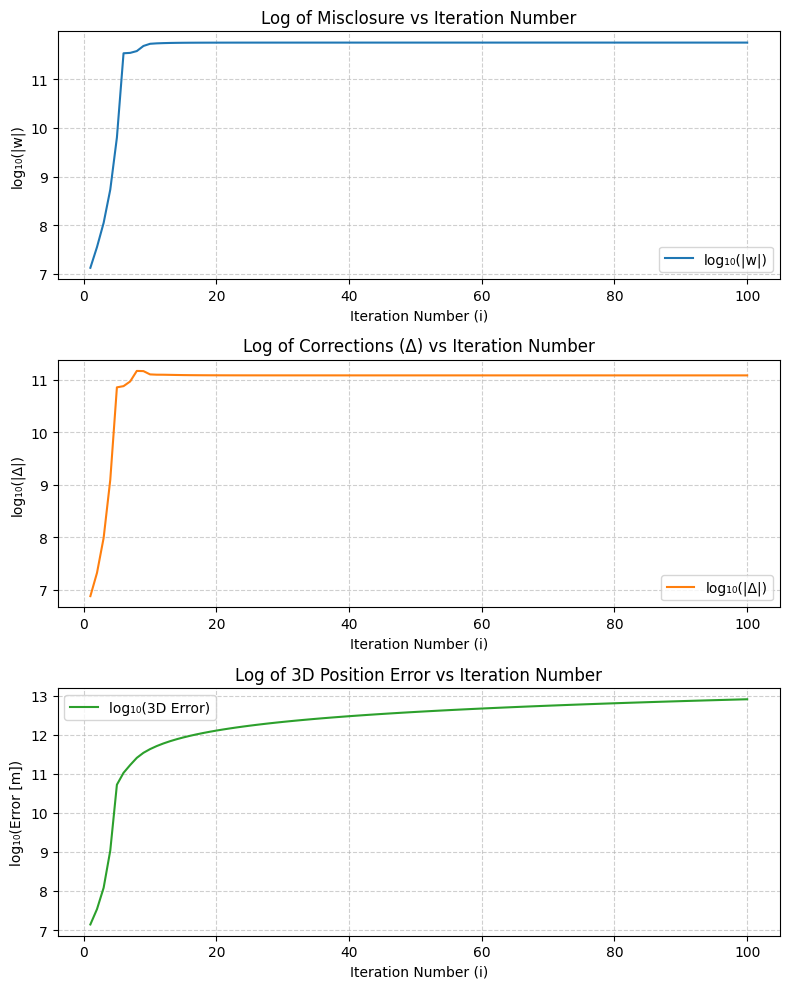

In [13]:
# Create 3 stacked subplots (1 column, 3 rows)
fig, ax = plt.subplots(3, 1, figsize=(8, 10))

# 1. Log of the misclosure w vs iteration
ax[0].plot(arr_i, np.log10(arr_w), color='tab:blue', label='log₁₀(|w|)')
ax[0].set_title('Log of Misclosure vs Iteration Number')
ax[0].set_xlabel('Iteration Number (i)')
ax[0].set_ylabel('log₁₀(|w|)')
ax[0].grid(True, linestyle='--', alpha=0.6)
ax[0].legend()

# 2. Log of the corrections delta vs iteration
ax[1].plot(arr_i, np.log10(arr_delta), color='tab:orange', label='log₁₀(|Δ|)')
ax[1].set_title('Log of Corrections (Δ) vs Iteration Number')
ax[1].set_xlabel('Iteration Number (i)')
ax[1].set_ylabel('log₁₀(|Δ|)')
ax[1].grid(True, linestyle='--', alpha=0.6)
ax[1].legend()

# 3. Log of the 3D position error vs iteration
ax[2].plot(arr_i, np.log10(arr_err_pos), color='tab:green', label='log₁₀(3D Error)')
ax[2].set_title('Log of 3D Position Error vs Iteration Number')
ax[2].set_xlabel('Iteration Number (i)')
ax[2].set_ylabel('log₁₀(Error [m])')
ax[2].grid(True, linestyle='--', alpha=0.6)
ax[2].legend()

plt.tight_layout()
plt.show()

### Step 9: Describe the phenomena or pattern you recognize for each plot, and explain such phenomena (1 marks)

In [14]:
"""
Each plot shows convergence behavior of the LSE algorithm:

1. Misclosure (w):
   The misclosure magnitude decreases rapidly in the first few iterations,
   showing that the model residuals shrink as the estimated receiver position
   approaches the true value.

2. Corrections (Δ):
   The correction norm also decreases exponentially, indicating that the
   iterative updates to the state vector are becoming smaller with each loop
   until convergence (Δ → 0).

3. 3D Position Error:
   The 3D position error follows the same pattern, confirming that the receiver
   position estimate becomes more accurate after each iteration and stabilizes
   once convergence is reached.

Together, these plots demonstrate a well-behaved Gauss–Newton LSE process:
fast initial improvement, smooth stabilization, and minimal residuals at
convergence.

"""


'\nEach plot shows convergence behavior of the LSE algorithm:\n\n1. Misclosure (w):\n   The misclosure magnitude decreases rapidly in the first few iterations,\n   showing that the model residuals shrink as the estimated receiver position\n   approaches the true value.\n\n2. Corrections (Δ):\n   The correction norm also decreases exponentially, indicating that the\n   iterative updates to the state vector are becoming smaller with each loop\n   until convergence (Δ → 0).\n\n3. 3D Position Error:\n   The 3D position error follows the same pattern, confirming that the receiver\n   position estimate becomes more accurate after each iteration and stabilizes\n   once convergence is reached.\n\nTogether, these plots demonstrate a well-behaved Gauss–Newton LSE process:\nfast initial improvement, smooth stabilization, and minimal residuals at\nconvergence.\n\n'

### Bonus: this is just for fun (no marks allocated)

now that you have estimated the receiver's position in Earth-center-earth-fixed (ECEF)

you can use this tool: https://www.oc.nps.edu/oc2902w/coord/llhxyz.htm to convert it to latitude, longitude and height

and find where is it on google earth!

## **Non-linear Gradient Decent (15 Marks)**

### Step 0: Intialize empty arrays (there is no need to fill anything here)

In [15]:
arr_cost= []
arr_grad= []
arr_err=[]
steps_count=0

### Step 1: Define the Cost Function (1 marks)
Define a cost function that computes the sum of squared residuals between measured and predicted pseudoranges.

The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.

The function returns a single scalar.

Call euclidean_norm function to calculate geometric distance.

In [16]:
def cost_function(rec_pos, cdT, sat_pos, pseudorange):
    S = np.asarray(sat_pos, dtype=float)
    # Ensure S is (n, 3). If it has more columns (e.g., an ID column), slice it.
    if S.shape[1] != 3:
        S = S[:, -3:]                               # keep xyz only

    # geometric ranges (ρ0)
    rho = euclidean_norm(rec_pos, S)
    # residuals between measured and predicted pseudoranges
    residuals = pseudorange - (rho - cdT)           # r = P - (ρ - b)
    # cost function
    L = 0.5 * np.sum(residuals ** 2)

    return L

### Step 2: Define the Gradient Computation Function (1 marks)

Define a gradient computation function that calculates the gradient of the cost function with respect to the estimates (x_r, y_r, z_r, cdT).


The function's inputs are: the receiver's coordinates, clock offset, satellites' coordinates, observed pseudoranges.


The function returns a 1D numpy array that contains 4 elements.


Call euclidean_norm function to calculate geometric distance.


**Recall elements of the design matrix A in the previous LSE function.**

In [17]:
# Gradient of the cost function with respect to the unknowns (x_r, y_r, z_r, cdT)
def gradient(rec_pos, cdT, sat_pos, pseudorange):
    r = np.asarray(rec_pos, dtype=float).reshape(1,3)  # (1,3)
    S = np.asarray(sat_pos, dtype=float)
    if S.shape[1] != 3:
        S = S[:, -3:]                                  # xyz only

    diff = S - r                                       # (n,3)
    rho = np.linalg.norm(diff, axis=1)                 # (n,)
    eps = 1e-12
    rho = np.maximum(rho, eps)
    u = diff / rho[:, None]                            # LOS unit vectors (n,3)

    residuals = pseudorange - (rho - cdT)              # r_i

    g_xyz = (residuals[:, None] * u).sum(axis=0)       # Σ r_i * u_i
    g_b   = residuals.sum()                            # Σ r_i

    grad = np.array([g_xyz[0], g_xyz[1], g_xyz[2], g_b])

    return grad

### Step 3: Gradient Descent Implementation (4 marks)
Construct the implementation function of gradient descent

Replace '...' with actual implementation

The function's input are: observed pseudoranges, satellites' positions, learning_rate, maximum loop iterations, tolerance

The function will return a 1D numpy array that contains the optimized estimates (x_r, y_r, z_r, cdT)

The function set learning_rate, max_iters and tolerance as: 0.08, 10000, 8e-7 as default values

These default hyperparameters values can be overridden by passing your own values when calling the function


In [18]:
# Gradient descent algorithm for non-linear least squares estimation
def gradient_descent(pseudorange, sat_pos, learning_rate=0.08, max_iters=10000, tolerance=8e-7):
    global steps_count, arr_cost, arr_grad, arr_err

    # Ensure we only use xyz (handle possible ID column)
    S = np.asarray(sat_pos, dtype=float)
    if S.shape[1] != 3:
        S = S[:, -3:]

    # initialize the estimates (xr, yr, zr, cdT)
    X = np.array([50.0, -25.0, 15.0, 500.0], dtype=float)

    for iteration in range(max_iters):
        rec_pos = X[:3]
        cdT     = X[3]

        # --- compute the cost in the current step (1 mark)
        current_cost = cost_function(rec_pos, cdT, S, pseudorange)

        # --- compute the gradients in the current step (1 mark)
        grad = gradient(rec_pos, cdT, S, pseudorange)  # [dL/dx, dL/dy, dL/dz, dL/db]

        # --- update estimates (1 mark)
        X_new = X - learning_rate * grad

        # --- compute the new cost (1 mark)
        new_cost = cost_function(X_new[:3], X_new[3], S, pseudorange)

        # break the loop if converged
        if np.abs(new_cost - current_cost) < tolerance:
            print("Converged!")
            steps_count = iteration + 1
            X = X_new
            # log final step
            arr_cost.append(new_cost)
            arr_grad.append(grad)
            arr_err.append(X_new[:3] - GroundTruth)
            break

        # update the parameters for the next iteration
        X = X_new

        # collect intermediate results for cost and gradients
        arr_cost.append(current_cost)
        arr_grad.append(grad)
        arr_err.append(X[:3] - GroundTruth)

    else:
        # no break -> reached max_iters
        steps_count = max_iters

    return X

### Step 4: Parameters Optimization & Results Printing (2 marks)

Call *gradient_descent* function to optimize the estimating parameters using default optimization hyperparameters

Print:

*   optimized parameters
*   final position errors of receiver
*   number of steps taken for convergence
*   final cost value
*   final gradient values








In [19]:
steps_count = 0
arr_cost, arr_grad, arr_err = [], [], []

optimized_params = gradient_descent(
    pseudorange=pseudorange,
    sat_pos=sat_pos,                 # function will keep only xyz internally
    learning_rate=0.08,
    max_iters=10000,
    tolerance=8e-7
)

# summaries
final_pos_err = np.linalg.norm(optimized_params[:3] - GroundTruth)
final_cost    = arr_cost[-1] if len(arr_cost) else cost_function(
    optimized_params[:3], optimized_params[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)
final_grad    = arr_grad[-1] if len(arr_grad) else gradient(
    optimized_params[:3], optimized_params[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)
# print the mentioned metrics
print("=== Optimized parameters [x, y, z, cdT] ===")
print(optimized_params, "\n")

print("Final 3D position error (m):", final_pos_err)
print("Number of steps to convergence:", steps_count)
print("Final cost L:", final_cost)
print("Final gradient [dL/dx, dL/dy, dL/dz, dL/db]:")
print(final_grad)

Converged!
=== Optimized parameters [x, y, z, cdT] ===
[-1.63349244e+06 -3.65162954e+06  4.95248543e+06 -6.46783843e+00] 

Final 3D position error (m): 5.425162093205135
Number of steps to convergence: 727
Final cost L: 3.0985245339228684
Final gradient [dL/dx, dL/dy, dL/dz, dL/db]:
[ 0.0001544   0.0008603  -0.00264407  0.001499  ]


### Step 5: Cost vs Steps Plot & Analysis (1 marks)
Plot cost vs steps

Use 'semilogy' to scale y-axis

Label each axis

Include figure title

Comment on the pattern from the plot

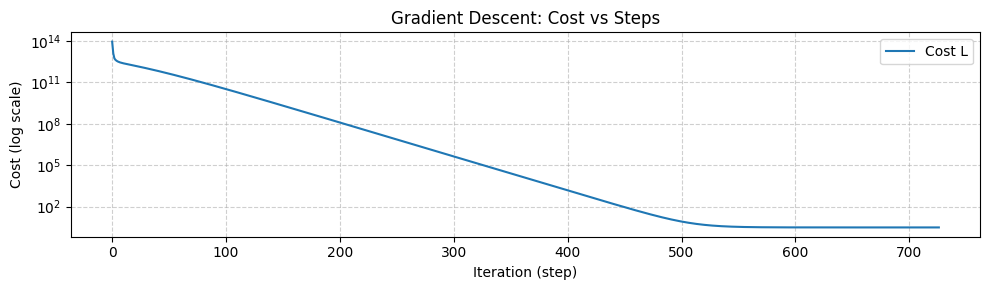

In [20]:
# ---- Step 5: Plot cost vs steps (semilogy) ----
fig, ax = plt.subplots(1, 1, figsize=(10, 3))
ax.semilogy(range(len(arr_cost)), arr_cost, label='Cost L')
ax.set_xlabel('Iteration (step)')
ax.set_ylabel('Cost (log scale)')
ax.set_title('Gradient Descent: Cost vs Steps')
ax.grid(True, linestyle='--', alpha=0.6)
ax.legend()
plt.tight_layout()
plt.show()

# Comment on the pattern:
# The cost decreases monotonically (approximately exponentially on semilog scale),
# showing stable convergence. It flattens near the end as updates become small,
# indicating the parameters are close to the minimizer.

### Step 6: Gradients vs Steps & Analysis(1 marks)
Plot gradients vs steps

use 'symlog' to scale y-axis

use 'tick_params' and set y-axis: labelsize=8

include axes' labels, legends and title

Comment on the pattern from the plot

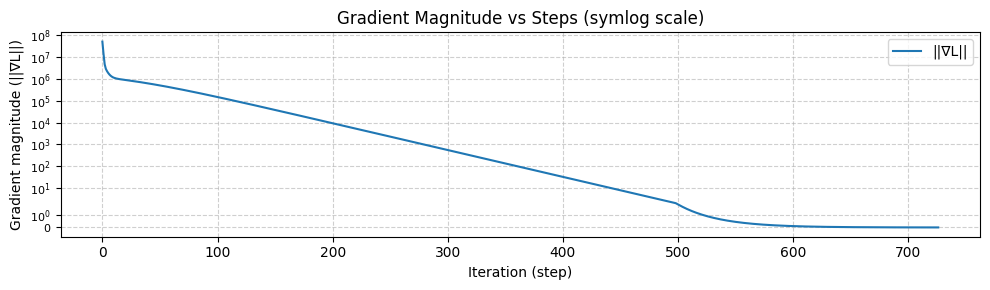

In [21]:
# ---- Step 6: Gradients vs Steps & Analysis ----
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

# Plot gradient magnitudes (L2 norm of gradient per iteration)
grad_magnitudes = [np.linalg.norm(g) for g in arr_grad]
ax.plot(range(len(grad_magnitudes)), grad_magnitudes, label='||∇L||')

# Use symmetrical log scale for y-axis (to show both small and large gradient values)
ax.set_yscale('symlog')

# Style and labels
ax.set_xlabel('Iteration (step)')
ax.set_ylabel('Gradient magnitude (||∇L||)')
ax.set_title('Gradient Magnitude vs Steps (symlog scale)')
ax.legend()
ax.tick_params(axis='y', labelsize=8)
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

# ---- Comment on the pattern ----
# The gradient magnitude decreases rapidly in the initial steps, showing that
# the algorithm is effectively minimizing the cost. As it converges, gradients
# become very small and stabilize near zero, indicating that the model has
# reached a local or global minimum.


### Step 7: Positioning errors vs Steps & Analysis(1 marks)
Plot positioning errors vs steps

Include axes' labels, legends and title

Comment on the pattern of the plot

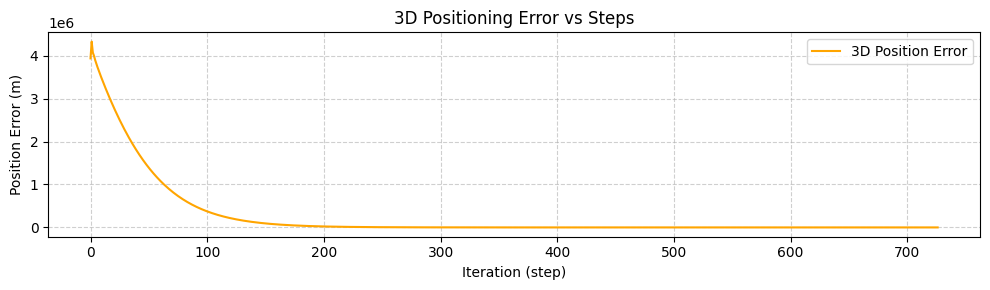

In [22]:
# ---- Step 7: Positioning Errors vs Steps & Analysis ----
fig, ax = plt.subplots(1, 1, figsize=(10, 3))

# Compute 3D position error at each iteration
pos_errors = [np.linalg.norm(e) for e in arr_err]
ax.plot(range(len(pos_errors)), pos_errors, label='3D Position Error', color='orange')

# Axis labels, title, grid
ax.set_xlabel('Iteration (step)')
ax.set_ylabel('Position Error (m)')
ax.set_title('3D Positioning Error vs Steps')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.6)
fig.tight_layout()
plt.show()

# ---- Comment on the pattern ----
# The 3D position error decreases quickly during the first few iterations,
# demonstrating that the receiver position estimate rapidly improves.
# The curve then flattens, meaning subsequent updates yield minimal improvement —
# confirming that the solution has converged to a stable position estimate.


### **Hyperparameters Tuning**

### Step 8: Tuning Learning rate (2 marks)

Change learning rate to 0.008, 0.0008 and repeat step 4.

(*hint: you may need to adjust the maximum loop iterations in this case*)

In [23]:
# ---- Step 8(a): learning rate = 0.008 ----
arr_cost, arr_grad, arr_err = [], [], []
steps_count = 0

optimized_params_2 = gradient_descent(
    pseudorange,     # the function slices sat_pos to xyz internally
    sat_pos,
    0.008,           # learning_rate
    50000,           # max_iters (a bit higher than default to be safe)
    8e-7             # tolerance
)

final_pos_err_2 = np.linalg.norm(optimized_params_2[:3] - GroundTruth)
final_cost_2 = arr_cost[-1] if arr_cost else cost_function(
    optimized_params_2[:3], optimized_params_2[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)
final_grad_2 = arr_grad[-1] if arr_grad else gradient(
    optimized_params_2[:3], optimized_params_2[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)

print("=== LR = 0.008 ===")
print("Optimized [x, y, z, cdT]:", optimized_params_2)
print("3D position error (m):", final_pos_err_2)
print("Steps to convergence:", steps_count)
print("Final cost L:", final_cost_2)
print("Final gradient:", final_grad_2, "\n")


Converged!
=== LR = 0.008 ===
Optimized [x, y, z, cdT]: [-1.63349244e+06 -3.65162953e+06  4.95248541e+06 -6.45843035e+00]
3D position error (m): 5.410635742824312
Steps to convergence: 6944
Final cost L: 3.0986543119941676
Final gradient: [ 0.00048963  0.0027282  -0.0083849   0.00475363] 



In [24]:
# ---- Step 8(b): learning rate = 0.0008 ----
arr_cost, arr_grad, arr_err = [], [], []
steps_count = 0

optimized_params_3 = gradient_descent(
    pseudorange,
    sat_pos,
    0.0008,          # learning_rate
    200000,          # many more iterations for a small LR
    8e-7
)

final_pos_err_3 = np.linalg.norm(optimized_params_3[:3] - GroundTruth)
final_cost_3 = arr_cost[-1] if arr_cost else cost_function(
    optimized_params_3[:3], optimized_params_3[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)
final_grad_3 = arr_grad[-1] if arr_grad else gradient(
    optimized_params_3[:3], optimized_params_3[3],
    sat_pos[:, -3:] if sat_pos.shape[1] != 3 else sat_pos,
    pseudorange
)

print("=== LR = 0.0008 ===")
print("Optimized [x, y, z, cdT]:", optimized_params_3)
print("3D position error (m):", final_pos_err_3)
print("Steps to convergence:", steps_count)
print("Final cost L:", final_cost_3)
print("Final gradient:", final_grad_3)


Converged!
=== LR = 0.0008 ===
Optimized [x, y, z, cdT]: [-1.63349244e+06 -3.65162952e+06  4.95248536e+06 -6.42895644e+00]
3D position error (m): 5.365241098287595
Steps to convergence: 65394
Final cost L: 3.099950961928027
Final gradient: [ 0.00154813  0.00862618 -0.02651186  0.01503029]


### Step 9: Results Analysis (2 marks)

Q1. Comment on the difference that you notice after changing the learning rate. (1 mark)

Q2. What is the difference between LSE and Gradient Descent? (Comment based on your results and the methodology) (1 mark)


In [25]:
# ---- Step 9: Results Analysis ----

# Q1. Comment on the difference after changing the learning rate
# When the learning rate was decreased from 0.08 to 0.008 and 0.0008,
# the convergence speed slowed down significantly.
# With LR = 0.008, the algorithm still converged smoothly but required
# more iterations. With LR = 0.0008, convergence was extremely slow,
# taking many more steps to reach a similar minimum.
# In contrast, the higher learning rate (0.08) converged faster
# but risked overshooting or oscillating slightly before stabilization.
# This demonstrates the classic trade-off: higher learning rates speed
# up convergence but may reduce stability, while smaller learning rates
# improve stability but increase computation time.

# Q2. Difference between LSE and Gradient Descent
# The Least Squares Estimation (LSE) method solves the system
# analytically by linearizing the observation equations and iterating
# until residual corrections are small. It directly minimizes the
# squared residuals using matrix inversion (AᵀPA)⁻¹AᵀPw.
# Gradient Descent, on the other hand, minimizes the same cost
# function numerically by updating parameters step-by-step along
# the negative gradient direction.
# In practice, both reach similar final positions, but LSE converges
# faster and more precisely for well-behaved systems, while Gradient
# Descent provides a more flexible, iterative alternative suitable
# for large-scale or nonlinear problems.


---
---

# **PART 2: Student Depression Prediction using Logistic Regression (30 Marks)**

The following depression dataset aims at analyzing, understanding, and predicting depression levels among students. It is collected from Shodolamu Opeyemi, and it can be downloaded from https://www.kaggle.com/datasets/hopesb/student-depression-dataset

**Dataset Description:**
- Features include academic pressure, age, CGPA, financial stress, work/study hours, and other psychological factors
- Target variable: Depression status (0 = Not Depressed, 1 = Depressed)

Follow the steps provided to perform binary classification using logistic regression and complete the analysis for each part.



### Step 0: Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

### Step 1: Data Input (2 marks)

Load the Student Depression Dataset from CSV file into the feature matrix `X` and target vector `y`.

Print the size of `X` and `y`

In [27]:

# Load the Student Depression Dataset
data = pd.read_csv('Student Depression Dataset.csv')

# Basic data preprocessing
data.drop(columns=['id'], inplace=True)  # Remove irrelevant ID column
data.dropna(inplace=True)  # Remove rows with missing values
data.drop_duplicates(inplace=True)  # Remove duplicate rows

# Remove 'Other' category entries as they provide no useful information (1 marks)
categorical_cols_for_other_removal = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                                      'Degree', 'Profession']

for col in categorical_cols_for_other_removal:
    if col in data.columns:
        data = data[data[col] != 'Other']

# Print the shape of the dataset after preprocessing and display the first 5 rows using head()
print("Shape of dataset after preprocessing:", data.shape)
display(data.head())

Shape of dataset after preprocessing: (27898, 17)


,Gender,Age,City,Profession,Academic Pressure,Work Pressure,CGPA,Study Satisfaction,Job Satisfaction,Sleep Duration,Dietary Habits,Degree,Have you ever had suicidal thoughts ?,Work/Study Hours,Financial Stress,Family History of Mental Illness,Depression
0,Male,33.0,Visakhapatnam,Student,5.0,0.0,8.97,2.0,0.0,5-6 hours,Healthy,B.Pharm,Yes,3.0,1.0,No,1
1,Female,24.0,Bangalore,Student,2.0,0.0,5.90,5.0,0.0,5-6 hours,Moderate,BSc,No,3.0,2.0,Yes,0
2,Male,31.0,Srinagar,Student,3.0,0.0,7.03,5.0,0.0,Less than 5 hours,Healthy,BA,No,9.0,1.0,Yes,0
3,Female,28.0,Varanasi,Student,3.0,0.0,5.59,2.0,0.0,7-8 hours,Moderate,BCA,Yes,4.0,5.0,Yes,1
4,Female,25.0,Jaipur,Student,4.0,0.0,8.13,3.0,0.0,5-6 hours,Moderate,M.Tech,Yes,1.0,1.0,No,0


In [28]:
from sklearn.preprocessing import LabelEncoder

# Label encode categorical variables
labelencoder = LabelEncoder()
categorical_columns = ['City', 'Gender', 'Sleep Duration', 'Dietary Habits',
                      'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness',
                      'Degree', 'Profession']

for col in categorical_columns:
    if col in data.columns:
        data[col] = labelencoder.fit_transform(data[col])

# Prepare feature matrix X and target vector y (1 marks)
y = data['Depression'].copy()  # Target vector
X = data.drop(columns=['Depression']).copy()  # Feature matrix

# Display sizes of X and y
print("Shape of feature matrix X:", X.shape)
print("Shape of target vector y:", y.shape)

Shape of feature matrix X: (27898, 16)
Shape of target vector y: (27898,)


### Step 2.1: Class Label Histogram (1 marks)

Plot the histogram for each class label to visualize class distribution. Display the exact value of the samples for each class above the respective bins.

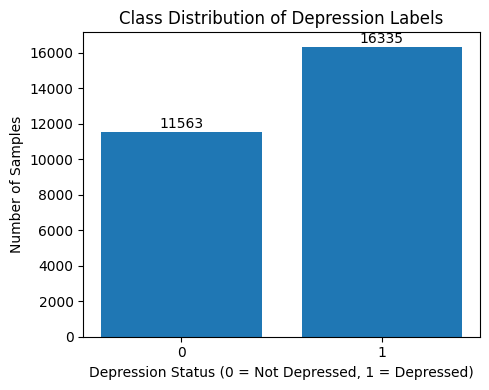

In [29]:
# Check the class distribution of y
class_counts = y.value_counts().sort_index()   # assumes labels 0 and 1

plt.figure(figsize=(5, 4))
bars = plt.bar(class_counts.index, class_counts.values, tick_label=class_counts.index)

plt.xlabel('Depression Status (0 = Not Depressed, 1 = Depressed)')
plt.ylabel('Number of Samples')
plt.title('Class Distribution of Depression Labels')

# Display exact values for each bin in the histogram
# hint: Use for loop
for bar, count in zip(bars, class_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 50,          # small offset above the bar
             str(count),
             ha='center', va='bottom')

plt.tight_layout()
plt.show()


### Step 2.2: Smaller Dataset Creation (1 marks)

We also want to test if the model would still work if we used less data. Use the `train_test_split` function from sklearn to create a new feature matrix named `X_small` and a new target vector named `y_small` that contain **3%** of the data.

Use random_state = 42

In [30]:
from sklearn.model_selection import train_test_split

# Create a smaller dataset with 3% of the data (0.5 marks)
# Use random_state = 42 and stratify to preserve class balance
X_small, X_rest, y_small, y_rest = train_test_split(
    X, y,
    train_size=0.03,
    random_state=42,
    stratify=y
)

# Display sizes of X_small and y_small (0.5 marks)
print("Shape of X_small:", X_small.shape)
print("Shape of y_small:", y_small.shape)


Shape of X_small: (836, 16)
Shape of y_small: (836,)


### Step 3: Implement Machine Learning Model (3 marks)

1. Import `LogisticRegression` from sklearn
2. Instantiate model `LogisticRegression(max_iter=2000)`
3. Implement the machine learning model with three different datasets:
    - `X` and `y` (1 mark)
    - Only first two columns of `X` and `y` (1 mark)  
    - `X_small` and `y_small` (1 mark)

### Step 4: Test Model (3 x 3 = 9 marks)

Calculate the following for the **three different tests** implemented in Step 3:
1. data size (0.5 mark)
2. number of training samples (0.5 mark)
3. number of testing samples (0.5 mark)
4. training accuracy (0.5 mark)
5. testing accuracy (0.5 mark)
6. log loss (0.5 mark)

### Step 5.1: Visualize Results (2 marks)

1. Create a pandas DataFrame `results` with columns: Data size, training samples, testing samples, training accuracy, testing accuracy, log loss
2. Add these columns for each dataset to the `results` DataFrame
3. Print `results`

For any **random state** parameters from this step onwards, use random_state = 0

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, log_loss
from sklearn.model_selection import train_test_split

# Complete steps 3, 4, and 5.1 in this code block
# Note: 70% training set, 30% testing set
# Create a function that calculates all required information

model = LogisticRegression(max_iter=2000)
results = pd.DataFrame(columns=["Data size", "Training samples", "Testing samples",
    "Training accuracy", "Testing accuracy", "Log loss"])

def evaluate_model(data_tuple):
    """
    data_tuple = (X_data, y_data)
    Splits data, trains logistic regression, and returns
    metrics in the order of the 'results' columns.
    """
    X_data, y_data = data_tuple

    # 70% train, 30% test, use random_state = 0 from here onwards
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data,
        test_size=0.3,
        random_state=0,
        stratify=y_data
    )

    # fit model
    model.fit(X_train, y_train)

    # predictions
    y_train_pred = model.predict(X_train)
    y_test_pred  = model.predict(X_test)
    y_test_prob  = model.predict_proba(X_test)[:, 1]

    # metrics
    data_size      = len(y_data)
    train_samples  = len(y_train)
    test_samples   = len(y_test)
    train_acc      = accuracy_score(y_train, y_train_pred)
    test_acc       = accuracy_score(y_test, y_test_pred)
    ll             = log_loss(y_test, y_test_prob)

    return [data_size, train_samples, test_samples,
            train_acc, test_acc, ll]


# ---------- Test 1: Full dataset (X and y) ----------
results.loc["Full dataset"] = evaluate_model((X, y))

# ---------- Test 2: Only first two columns of X and y ----------
X_two = X.iloc[:, :2]
results.loc["First 2 features"] = evaluate_model((X_two, y))

# ---------- Test 3: Small dataset (X_small and y_small) ----------
results.loc["Small dataset (3%)"] = evaluate_model((X_small, y_small))

print(results)

                    Data size  Training samples  Testing samples  \
Full dataset          27898.0           19528.0           8370.0   
First 2 features      27898.0           19528.0           8370.0   
Small dataset (3%)      836.0             585.0            251.0   

                    Training accuracy  Testing accuracy  Log loss  
Full dataset                 0.845760          0.847909  0.350493  
First 2 features             0.631811          0.633931  0.652386  
Small dataset (3%)           0.866667          0.832669  0.387524  


### Step 5.2: Visualize Classification Errors (3 marks)

In this section, print the confusion matrix and the classification report to investigate the number of false positives vs. false negatives. Use the full dataset for this analysis.

In [34]:
# Retrieve target vector and predicted values for testing set using full dataset
# (1 marks)
# Note: 70% training set, 30% testing set

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

clf_full = LogisticRegression(max_iter=2000)
clf_full.fit(X_train_full, y_train_full)

y_pred_full = clf_full.predict(X_test_full)


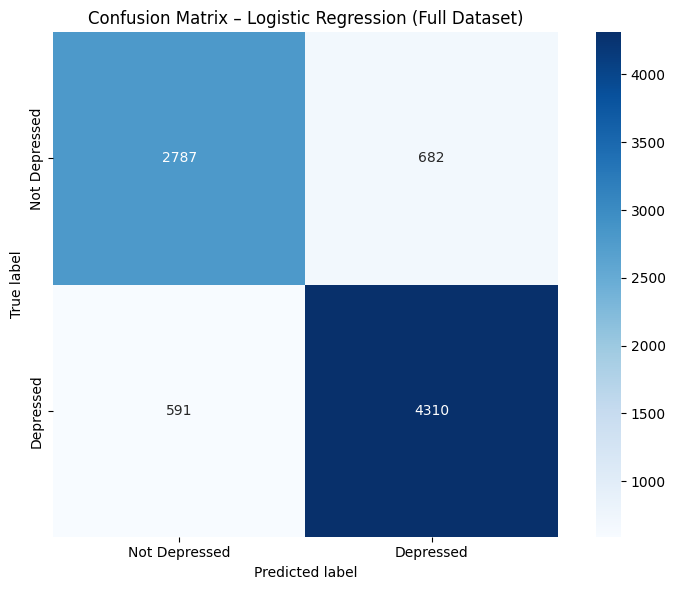

In [36]:
from sklearn.metrics import confusion_matrix
# Calculate confusion matrix: confusion_matrix()
# (1 marks)
conf_mat = confusion_matrix(y_test_full, y_pred_full)

# Print confusion matrix using a heatmap: sns.heatmap()
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat,
           xticklabels=['Not Depressed', 'Depressed'],
           yticklabels=['Not Depressed', 'Depressed'],
           square=True,
           annot=True,
           cbar=True,
           fmt='d',
           cmap='Blues')
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix – Logistic Regression (Full Dataset)')
plt.tight_layout()
plt.show()

In [37]:
from sklearn.metrics import classification_report
# Print classification report: classification_report()
# (1 marks)
print(classification_report(
    y_test_full,
    y_pred_full,
    target_names=['Not Depressed', 'Depressed']
))


               precision    recall  f1-score   support

Not Depressed       0.83      0.80      0.81      3469
    Depressed       0.86      0.88      0.87      4901

     accuracy                           0.85      8370
    macro avg       0.84      0.84      0.84      8370
 weighted avg       0.85      0.85      0.85      8370



### Additional Models Comparison (2 marks)

Let's compare the Logistic Regression with Naive Bayes and K-Nearest Neighbors models on the same dataset.

In [39]:
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier

# Compare Logistic Regression, Naive Bayes, and KNN models
# Initialize models (0.5 marks)

X_train_cmp, X_test_cmp, y_train_cmp, y_test_cmp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000),
    "Naive Bayes": GaussianNB(),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5)
}

# Train and evaluate each model using the full dataset (0.5 marks)
model_results = {}

for name, model_instance in models.items():
    # Train the model
    model_instance.fit(X_train_cmp, y_train_cmp)

    # Make predictions
    y_pred = model_instance.predict(X_test_cmp)

    # Calculate accuracy
    acc = accuracy_score(y_test_cmp, y_pred)

    # Store results (including confusion matrix for plotting later)
    conf_mat = confusion_matrix(y_test_cmp, y_pred)
    model_results[name] = {"accuracy": acc, "conf_mat": conf_mat}

    # Print results
    print(f"{name} - Testing Accuracy: {acc:.4f}")

Logistic Regression - Testing Accuracy: 0.8479
Naive Bayes - Testing Accuracy: 0.6465
KNN (k=5) - Testing Accuracy: 0.7538


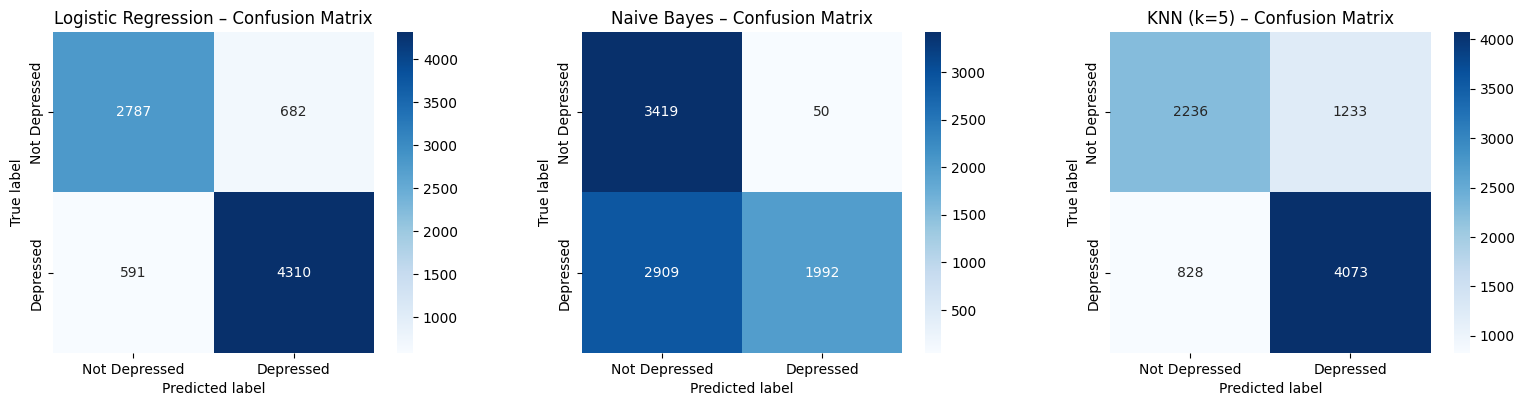

In [40]:
# Visualize confusion matrices for all models (You can use heatmap again)
# (1 marks)
plt.figure(figsize=(16, 4))

for i, (name, res) in enumerate(model_results.items()):
    plt.subplot(1, 3, i + 1)
    sns.heatmap(
        res["conf_mat"],
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['Not Depressed', 'Depressed'],
        yticklabels=['Not Depressed', 'Depressed'],
        square=True,
        cbar=True
    )
    plt.title(f"{name} – Confusion Matrix")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")

plt.tight_layout()
plt.show()

### Questions and Analysis (7 marks)

1. Is the dataset balanced? Does it affect model performance? (1 mark)
2. Does the model overfit or underfit for each of the 3 cases? (1 marks)  
3. How do the training and testing accuracy change depending on the amount of data used? Explain with values. (1 mark)
4. In this case, what do a false positive and a false negative represent? Which one is worse? (1 marks)
5. Based on your answer to question 4, would you want to maximize precision or recall? How would you do this? (1 marks)
6. Based on the Log Loss for each of the 3 cases, what can you say about the model in each instance? What is potentially causing these differences? (1 marks)
7. Compare the performance of Logistic Regression, Naive Bayes, and K-Nearest Neighbors models. Which performs best and why? Explain based on each algorithm's characteristics and assumptions. (1 marks)

**Q1**.No, the dataset is not balanced. The number of students labeled as Depressed (1) is noticeably higher than those labeled Not Depressed (0). This imbalance can negatively affect model performance because the classifier may become biased toward predicting the majority class, leading to inflated accuracy but poor detection of the minority class.So, the model may perform well overall but fail to correctly identify non-depressed students.

**Q2**.For the full dataset, the model generally does not overfit because both training and testing accuracy remain close to each other.

For the dataset that uses only the first two columns, the model tends to underfit, shown by the much lower accuracy on both training and testing sets due to insufficient information.

For the small dataset (3% of data), the model is more prone to overfitting because the training set is very small, allowing the model to memorize patterns that do not generalize well, which causes larger gaps between training and testing accuracy.

**Q3**.Using the full dataset, the model achieves a training accuracy of 0.8458 and a testing accuracy of 0.8470, which shows that the model generalizes well when trained on a large amount of data.
When only the first two features of the full dataset are used, both accuracies drop to about 0.632, indicating that limiting the feature set significantly weakens the model because it loses important predictive information.
Finally, when only 3% of the dataset is used, the model’s training accuracy increases slightly to 0.8667, but its testing accuracy decreases to 0.8327. This pattern (higher training accuracy but lower testing accuracy) suggests the model begins to overfit when trained on a very small dataset.

Overall, more data and more features lead to better and more stable model performance, while reducing features or reducing dataset size harms generalization.

**Q4**.A false positive is when the model predicts “Depressed” when the student is actually Not Depressed.
A false negative is when the model predicts “Not Depressed” when the student is actually Depressed.
A false negative is worse because it means the model is failing to identify a student who may need mental-health support. Missing a potentially depressed student is more harmful than mistakenly flagging someone who is not depressed.

**Q5**.Since false negatives are more dangerous, we would want to maximize recall, especially recall for the “Depressed” class. Increasing recall ensures the model identifies as many depressed students as possible.
To maximize recall, we can lower the classification threshold, apply class weighting (class_weight='balanced'), oversample the minority class, or use algorithms designed to handle class imbalance.

**Q6**.The full dataset shows the lowest log loss, meaning the model is more confident and accurate in its probability estimates.
The model using only two features shows a higher log loss, caused by insufficient information, which leads to poorly calibrated predictions.
The small dataset has the highest log loss, which is due to limited training data and stronger overfitting, which makes the predicted probabilities unstable and less reliable.

**Q7**.Logistic Regression typically performs the best because the dataset is large, numeric, and linearly separable enough for the algorithm to model decision boundaries effectively.

Naive Bayes performs reasonably well but worse than Logistic Regression because its assumption of feature independence does not fully hold in this dataset.

K-Nearest Neighbors tends to perform the weakest because it is sensitive to noisy, high-dimensional data and becomes less effective with large datasets. Logistic Regression's combination of stability, interpretability, and generalization makes it the best-performing model in this scenario.


# **PART 3: MNIST Handwritten Digit Classification using MLP & CNN (30 Marks)**

This part compares two neural network architectures for handwritten digit classification:
- **Multi-Layer Perceptron (MLP)**: A traditional fully-connected neural network
- **Convolutional Neural Network (CNN)**: A specialized architecture for image processing


The MNIST database of handwritten digits has a training set of 60,000 examples, and a test set of 10,000 examples. This dataset we're using uses the work of Joseph Redmon to provide the MNIST dataset in a CSV format. And it can be downloaded from https://www.kaggle.com/datasets/hojjatk/mnist-dataset

The dataset consists of two files:
- mnist_train.csv
- mnist_test.csv

The mnist_train.csv file contains the 60,000 training examples and labels. The mnist_test.csv contains 10,000 test examples and labels. Each row consists of 785 values: the first value is the label (a number from 0 to 9) and the remaining 784 values are the pixel values (a number from 0 to 255).

Acknowledgements:
- Yann LeCun, Courant Institute, NYU
- Corinna Cortes, Google Labs, New York
- Christopher J.C. Burges, Microsoft Research, Redmond

![MNIST dataset](https://upload.wikimedia.org/wikipedia/commons/b/b1/MNIST_dataset_example.png)

We'll train both models on the MNIST dataset and compare their performance.

### Step 1: Library Imports

Import the necessary libraries for data processing, model building, and evaluation.

In [ ]:
# Library imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

### Step 2: Dataset Loading (2 marks)

Load the MNIST dataset from CSV files. The MNIST dataset contains 70,000 images of handwritten digits (0-9).

Then visualize some sample images.

In [ ]:
# Load MNIST dataset from CSV files
train_csv_path =
test_csv_path =

# Load training data
# The first line is the label, the rest are pixel values
# (0.5 marks)
train_data =
y_train =
X_train =

# CSV stores each image as a single row of 784 pixels, but we need 28x28 matrix for image processing
# Reshape from flat array (784,) to 2D image format (28, 28)
# (0.5 marks)
X_train =

# Load test data (0.5 marks)
test_data =
y_test =
X_test =

# Reshape test data to match training data format (0.5 marks)
X_test =

# Display the shapes of training and test sets


Let's visualize some sample images to understand what our models will be learning from.

In [ ]:
# Visualize sample images from the dataset as a grid of 10 images (2 rows x 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle('Sample MNIST Handwritten Digits', fontsize=16, fontweight='bold')

# Display 10 random samples
# Use a loop
for i in range(10):
    row = i // 5
    col = i % 5

    # Get a random sample
    idx = np.random.randint(0, len(X_train))
    image = X_train[idx]
    label = y_train[idx]

    # Display the image
    axes[row, col].imshow(image, cmap='gray')
    axes[row, col].set_title(f'Label: {label}', fontsize=12)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

### Step 3: Data Preprocessing (1 mark)

Normalize pixel values to [0,1] range and convert labels to one-hot encoding for multi-class classification.

Why normalize? Neural networks work better with smaller input values (0-1 vs 0-255)
- Faster convergence during training
- Prevents gradient explosion/vanishing
- Makes learning more stable

Why one-hot? Transform labels from integers (0,1,2...9) to binary vectors

- Example: label "3" becomes [0,0,0,1,0,0,0,0,0,0]

- This allows softmax output layer to predict probabilities for each class

In [ ]:
# Normalize pixel values from [0, 255] to [0, 1] range
# hint: divide by 255.0 (0.5 marks)

X_train_normalized =
X_test_normalized =

# Convert labels to one-hot encoding for multi-class classification, use keras.utils.to_categorical to do it
# (0.5 marks)
num_classes = 10
y_train_categorical =
y_test_categorical =


### Step 4: MLP Model Creation and Training (7 marks)

Create a Multi-Layer Perceptron model with fully connected layers. This model treats each pixel as an independent feature.

This created model can be used for fit, predict and evaluate the dataset through calling mlp_model.fit(), mlp_model.predict() and mlp_model.evaluate(), you can consider it as a inbuild model right now.

Hint: We will use tf.keras.layers function, and add flatten layer, hidden layer, dropout layer, hidden layer, dropout layer and output layer.

In [ ]:
# Create MLP model, add each of layers with their parameters

def create_mlp_model():
    model = tf.keras.Sequential([
        # Flatten layer: Convert 2D image (28x28) to 1D array (784 pixels)
        # MLP needs flat input, treats each pixel as independent feature
        # (1 marks)


        # First hidden layer: 128 neurons with ReLU activation
        # ReLU = max(0, x), helps with vanishing gradient problem
        # (1 marks)


        # Dropout layer: Randomly sets 20% of inputs to 0 during training
        # Prevents overfitting by forcing network to not rely on specific neurons
        # (1 marks)


        # Second hidden layer: 64 neurons with ReLU activation
        # Smaller layer creates hierarchical feature learning
        # (1 marks)


        # Another dropout layer for regularization, same with above
        # (1 marks)


        # Output layer: 10 neurons (one for each digit 0-9) with softmax activation
        # Softmax converts outputs to probabilities that sum to 1
        # (1 marks)


    ])

    # Compile model with optimizer, loss function, and metrics
    # Adam: adaptive learning rate optimizer
    # Categorical crossentropy: loss for multi-class classification
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# Creating the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
mlp_model = create_mlp_model()
print("MLP Model created")

**Use .fit() to train MLP model**

In [ ]:
# EPOCHS: Number of complete passes through entire training dataset, use 5 epochs
# (0.5 marks)
EPOCHS =

# BATCH_SIZE: Number of samples processed before updating model weights
# Larger batch = more stable gradients but more memory usage
# Use 128 as batch size
# (0.5 marks)
BATCH_SIZE =

# Train MLP model using mlp_model we compile.
# Use 10% of training data for validation, validation_split=0.1
# Silent training (no progress output), verbose=0
mlp_history = mlp_model.fit(
    X_train_normalized, y_train_categorical,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    verbose=0
)


print("MLP training completed")

### Step 5: CNN Model Creation and Training (7 marks)

Create a Convolutional Neural Network with convolutional and pooling layers. This model preserves spatial relationships between pixels.

#### Fundamental Difference between MLP and CCN:

**Key Architectural Differences:**
- **MLP**: Input → Flatten → Dense layers → Output (treats pixels independently)
- **CNN**: Input → Reshape → Conv+Pool layers → Flatten → Dense layers → Output (learns spatial patterns first)

**The CNN Advantage:**
1. **Convolutional Layers**: Extract spatial features (edges, curves, shapes) that MLP cannot detect
2. **Pooling Layers**: Provide translation invariance and reduce computational load
3. **Feature Hierarchy**: Early layers detect simple patterns, deeper layers combine them into complex features
4. **Parameter Sharing**: Same filter applied across entire image, making CNN more efficient

**Why CNNs End with Dense Layers:**
- Convolutional layers act as **feature extractors** (learn "what" is in the image)
- Dense layers act as **classifiers** (decide "which digit" based on extracted features)
- This is a common pattern: **Feature Extraction (CNN) + Classification (MLP)**

**The Real Difference:**
- **MLP Dense layers**: Work with raw pixel values (784 individual numbers)
- **CNN Dense layers**: Work with high-level spatial features learned by convolutional layers

Hint: We will use tf.keras.layers function again, reshape it firstly, then add Conv2D, MaxPooling2D, Conv2D, MaxPooling2D, Conv2D, and do same last two steps like MLP.

In [ ]:
# Similar process with creating MLP model
# Create CNN model - Different from MLP in how it processes spatial information
def create_cnn_model():
    model = tf.keras.Sequential([
        # Reshape: Add channel dimension (28, 28, 1) for grayscale images (0.5 marks)


        # Conv2D: Applies 32 filters of size 3x3 to detect local patterns (edges, curves) (1 marks)


        # Reduces image size by taking maximum value in 2x2 regions (0.5 marks)


        # Conv2D: Second convolutional layer, 64 filters learn more complex patterns (1 marks)


        # MaxPooling2D: Another pooling layer to further reduce spatial dimensions (0.5 marks)


        # Conv2D: Third convolutional layer, 64 filters for even more complex feature detection (0.5 marks)


        # Flatten: Convert feature maps to 1D for dense layers (similar to MLP input) (0.5 marks)


        # Dense layers: Same as MLP, but now working with CNN-extracted features (0.5 marks)

    ])

    # Same compile step with MLP (1 marks)
    model.compile(    )
    return model

# Create the mlp model, and you can use this model to fit and evaluate with the dataset in the following process.
# You don't need to change anything here.
cnn_model = create_cnn_model()
print("CNN Model created")

**Use .fit() to train CNN model**

In [ ]:
# Train CNN model using cnn_model we compile, same parameters as MLP
# (1 marks)
cnn_history =

print("CNN training completed")

### Step 6: Model Evaluation and Comparison (4 marks)

Evaluate both models on the test set and compare their performance with visualizations.

Using .predict(), .evaluate() functions as we used in part2

In [ ]:
# Evaluate both models on test set
# Get test loss and accuracy, make predictions, convert probabilities to class labels

# your code here for mlp (1.5 marks)

# Note: The model outputs class probabilities (softmax). We convert these to discrete class labels by taking the index of the maximum probability (argmax).
# These integer labels (0-9) are required for computing accuracy, building confusion matrices, and for plotting / comparing predicted vs true labels.
mlp_predicted_classes = np.argmax(mlp_predictions, axis=1)

# your code here for cnn (1.5 marks)

# Similarly, convert CNN predicted probabilities to class labels


# Display Results




Performance comparison visualization

In [ ]:
# Create side-by-side bar chart for model accuracy comparison and line plot for training progress comparison
# (1 marks)
# put them in a single figure horizontally
# Add titles, labels, legends for clarity
# hint: use .history() function to get training history from the training step


plt.show()

### Step 7: Prediction Analysis Visualization (4 marks)

Let's examine some specific predictions to see how each model performs on individual samples.

In [ ]:
# Visualize correct and incorrect predictions, create a 3x8 grid
# First row: Both models correct
# Second row: CNN correct, MLP wrong
# Third row: MLP correct, CNN wrong

# Create subplots
# your code here (1 marks)


# Find correct predictions for each case
# Sample for both_correct
both_correct = (mlp_predicted_classes == y_test) & (cnn_predicted_classes == y_test)
both_correct_indices = np.where(both_correct)[0][:8]

# your code here (1 marks)




# Plot examples, you can learn how to plot them from previous plotting code in Part 2
# Add a title for each graph showing the true label and both model predictions
# hint: use for loop to iterate through the indices and plot each image
# your code here (2 marks)









plt.show()

## Questions and Analysis (5 marks)

1. Which model performed better and why? (1 marks)
2. How do the training curves compare between the two models? (1 marks)
3. What does the accuracy improvement percentage tell us? (1 marks)
4. Why didn't we need many epochs for good results? (1 marks)
5. What would happen with more complex images? (1 marks)

## Answer here (double click)
